# Stage 2 — Object Detector (15 classes): Pipeline Walkthrough

Like the classification notebook, this is not the primary way to run
training. The CLI remains the actual entry point:

```bash
python -m src.train_detection --config configs/detection/det_combined.yaml --framework all
```

This notebook replays the same logic using the actual functions from
`src/`, split into steps with explanation and visualization, for reading.

**Prerequisites for the cells below to run:**
1. The stage 2 dataset has been built:
   `python scripts/build_combined_dataset.py --task detection --sources gc10=... neu_det=... --out_dir data/combined/detection --negatives_dir data/raw/severstal_clean`
2. `pip install -r requirements.txt` (including `ultralytics` and `torchmetrics`)

Two frameworks are covered (sections 4-6): `ultralytics` (YOLOv8/YOLO11/
RT-DETR) and `torchvision` (Faster R-CNN/RetinaNet). The `RUN_TRAINING_*`
flags default to `False` in both training sections so opening this
notebook does not trigger a full run (detection training takes a long time).


In [1]:
import os
import sys
from pathlib import Path

if "__vsc_ipynb_file__" in globals():
    PROJECT_ROOT = Path(__vsc_ipynb_file__).resolve().parents[2]  # VS Code: cwd is the workspace, not the notebook dir
else:
    PROJECT_ROOT = Path.cwd().resolve().parents[1]  # Jupyter classic/Lab: cwd is the notebook's own dir

if not (PROJECT_ROOT / "requirements.txt").exists():
    raise RuntimeError(
        f"PROJECT_ROOT keliru: {PROJECT_ROOT} (gak ada requirements.txt di situ). "
        "Set manual sebelum lanjut, misal:\n"
        "    PROJECT_ROOT = Path('/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection')"
    )

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import yaml
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from src.data_loader import get_detection_dataloaders, build_ultralytics_data_yaml, IMAGENET_MEAN, IMAGENET_STD
from src.models.detection import build_model as build_torchvision_model
from src.utils.seed import get_device, set_seed
from src.class_mapping import combined_class_names_for

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")


Project root: /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection
CUDA available: False


## 1. Load config

`det_combined.yaml` is stage 2: the 15-class union (GC10-DET's 10 classes
plus NEU-DET's 6, with `inclusion` merged) plus negative samples from
Severstal (empty label = 0 objects, already handled by the loader).


In [2]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "detection" / "det_combined.yaml"
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print(yaml.dump(config, sort_keys=False))


experiment_name: steel-defect/detection/combined
dataset:
  name: combined
  root: data/combined/detection
  num_classes: 15
  class_names:
  - inclusion
  - scratches
  - crazing
  - patches
  - pitted_surface
  - rolled-in_scale
  - punching_hole
  - weld_line
  - crescent_gap
  - water_spot
  - oil_spot
  - silk_spot
  - waist_folding
  - crease
  - rolled_pit
img_size: 640
batch_size: 16
epochs: 120
num_workers: 4
seed: 42
frameworks:
  ultralytics:
    architectures:
    - yolov8s
    - yolo11s
    - rtdetr-l
    optimizer: auto
    lr0: 0.01
  torchvision:
    architectures:
    - fasterrcnn_resnet50_fpn_v2
    - retinanet_resnet50_fpn_v2
    optimizer:
      name: sgd
      lr: 0.005
      momentum: 0.9
      weight_decay: 0.0005
output_dir: results/detection/combined



In [3]:
set_seed(config.get("seed", 42))
device = get_device()  # CUDA > MPS (Apple Silicon) > CPU - lihat src/utils/seed.py
class_names = config["dataset"]["class_names"]

print(f"Device: {device}")
print(f"{len(class_names)} kelas: {class_names}")


Device: mps
15 kelas: ['inclusion', 'scratches', 'crazing', 'patches', 'pitted_surface', 'rolled-in_scale', 'punching_hole', 'weld_line', 'crescent_gap', 'water_spot', 'oil_spot', 'silk_spot', 'waist_folding', 'crease', 'rolled_pit']


## 2. Dataset format (YOLO: images/ + labels/)

Data is stored in YOLO format: `images/{train,val,test}/*.jpg` and
`labels/{train,val,test}/*.txt` (`class_id xc yc w h`, normalized 0-1).
Both frameworks consume this format directly:

- **ultralytics** (YOLO/RT-DETR) reads it via a `data.yaml` pointing at
  this folder
- **torchvision** (Faster R-CNN/RetinaNet) reads it through the custom
  `YoloDetectionDataset` (`src/data_loader.py`), which converts to the
  torchvision target format (`{boxes: xyxy absolute, labels}`, labels
  shifted +1 since index 0 is reserved for background)

Negative images (from Severstal, 0 objects) have an empty label file;
`YoloDetectionDataset` returns empty `boxes`/`labels` for these
automatically, no special-case code is needed.


In [4]:
data = get_detection_dataloaders(config)
train_ds = data["train_dataset"]

print(f"Train: {len(train_ds)} gambar")
print(f"Val:   {len(data['val_dataset'])} gambar")
print(f"Test:  {len(data['test_dataset'])} gambar")

# cari 1 sample yang beneran ada object-nya (bukan negative) buat divisualisasi
sample_image, sample_target = None, None
for i in range(len(train_ds)):
    image_t, target = train_ds[i]
    if len(target["labels"]) > 0:
        sample_image, sample_target = image_t, target
        break


Train: 3205 gambar
Val:   691 gambar
Test:  690 gambar


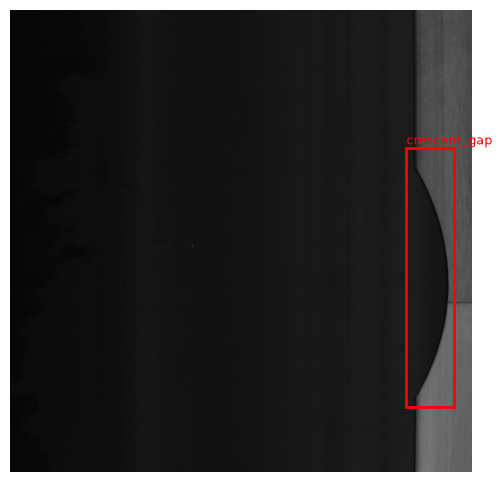

In [5]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


if sample_image is not None:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(denormalize(sample_image).permute(1, 2, 0).numpy())
    for box, label in zip(sample_target["boxes"].tolist(), sample_target["labels"].tolist()):
        x1, y1, x2, y2 = box
        cname = class_names[label - 1]  # -1: geser balik dari background-offset torchvision
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
        ax.text(x1, max(0, y1 - 5), cname, color="red", fontsize=9)
    ax.axis("off")
    plt.show()
else:
    print("Gak ketemu sample dengan object di dataset ini (cek apakah data udah di-build).")


## 3. Class remapping to the 15 canonical classes

GC10-DET (10 classes) and NEU-DET (6 classes) use different class names,
but `inclusion` appears in both. `scripts/build_combined_dataset.py`
remaps everything to canonical ids from `src/class_mapping.py` before
writing to `data/combined/detection/`, so the loader in this notebook does
not need to know about remapping at all — it reads the final class ids.


In [6]:
print(combined_class_names_for(["gc10", "neu_det"]))


['inclusion', 'scratches', 'crazing', 'patches', 'pitted_surface', 'rolled-in_scale', 'punching_hole', 'weld_line', 'crescent_gap', 'water_spot', 'oil_spot', 'silk_spot', 'waist_folding', 'crease', 'rolled_pit']


## 4. Two training paths: ultralytics vs torchvision

| | ultralytics (YOLOv8/YOLO11/RT-DETR) | torchvision (Faster R-CNN/RetinaNet) |
|---|---|---|
| Training loop | Internal to the `ultralytics` package, invoked via `model.train(...)` | Manual (`train_one_epoch_torchvision` in `src/train_detection.py`) |
| Pretrained weights | COCO, auto-downloaded (`yolov8s.pt`, etc.) | COCO, from `torchvision.models.detection` |
| mAP | Computed automatically by `ultralytics` (`model.val()`) | `torchmetrics.detection.MeanAveragePrecision` |
| MLflow | Built-in `ultralytics` autologging is disabled; logging is manual to match the torchvision path's schema | Manual from the start |


## 5. ultralytics path (YOLO/RT-DETR)

In [7]:
from ultralytics import YOLO, RTDETR
from ultralytics import settings as ultralytics_settings
ultralytics_settings.update({"mlflow": False})

demo_data_yaml = build_ultralytics_data_yaml(config, PROJECT_ROOT / "results" / "_notebook_demo" / "data.yaml")
print(demo_data_yaml.read_text())


path: /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/data/combined/detection
train: images/train
val: images/val
test: images/test
names:
  0: inclusion
  1: scratches
  2: crazing
  3: patches
  4: pitted_surface
  5: rolled-in_scale
  6: punching_hole
  7: weld_line
  8: crescent_gap
  9: water_spot
  10: oil_spot
  11: silk_spot
  12: waist_folding
  13: crease
  14: rolled_pit



In [8]:
RUN_TRAINING_ULTRALYTICS = True
DEMO_EPOCHS = 1
DEMO_FRACTION = 0.03   # fraction of train data (ultralytics built-in)
DEMO_IMGSZ = 320        # demo only, full training uses config["img_size"]
ultra_arch = config["frameworks"]["ultralytics"]["architectures"][0]

if RUN_TRAINING_ULTRALYTICS:
    model_cls = RTDETR if ultra_arch.startswith("rtdetr") else YOLO
    ultra_model = model_cls(f"{ultra_arch}.pt")
    ultra_model.train(
        data=str(demo_data_yaml),
        epochs=DEMO_EPOCHS,
        imgsz=DEMO_IMGSZ,
        batch=config["batch_size"],
        fraction=DEMO_FRACTION,
        device=str(get_device()),  # "mps" di Apple Silicon - tanpa ini ultralytics bisa aja balik ke CPU
    )
else:
    print(f"RUN_TRAINING_ULTRALYTICS=False, skip. Arsitektur contoh: {ultra_arch}")


Ultralytics 8.4.116 🚀 Python-3.12.9 torch-2.13.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/results/_notebook_demo/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.03, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, mult

/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overriding model.yaml nc=80 with nc=15

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding det

        1/1      2.38G      2.741      6.013      2.441         43        320: 100% ━━━━━━━━━━━━ 6/6 4.3s/it 25.5s0.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.5s/it 33.8s0.9ss
                   all        690       1136      0.269     0.0459   0.000348   8.85e-05

1 epochs completed in 0.018 hours.
Optimizer stripped from /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/runs/detect/train-3/weights/last.pt, 22.5MB
Optimizer stripped from /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/runs/detect/train-3/weights/best.pt, 22.5MB

Validating /Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/runs/detect/train-3/weights/best.pt...
Ultralytics 8.4.116 🚀 Python-3.12.9 torch-2.13.0 MPS (Apple M4)
Model summary (fused): 73 layers, 11,131,389 parameters, 0 gradients, 28.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━

## 6. torchvision path (Faster R-CNN/RetinaNet)

In [8]:
tv_arch = config["frameworks"]["torchvision"]["architectures"][0]
tv_model = build_torchvision_model(tv_arch, config["dataset"]["num_classes"], pretrained=True).to(device)

print(f"Arsitektur: {tv_arch}")
print(f"Total parameter: {sum(p.numel() for p in tv_model.parameters()):,}")


Arsitektur: fasterrcnn_resnet50_fpn_v2
Total parameter: 43,327,903


In [ ]:
from src.train_detection import train_one_epoch_torchvision, evaluate_torchvision, save_qualitative_predictions

RUN_TRAINING_TORCHVISION = True
DEMO_EPOCHS = 1

if RUN_TRAINING_TORCHVISION:
    tv_optimizer = torch.optim.SGD(tv_model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4)
    for epoch in range(1, DEMO_EPOCHS + 1):
        train_loss = train_one_epoch_torchvision(tv_model, data["train_loader"], tv_optimizer, device)
        print(f"epoch {epoch}: train_loss={train_loss:.4f}")
else:
    print("RUN_TRAINING_TORCHVISION=False, skip eksekusi.")


train:   0%|          | 0/200 [00:00<?, ?it/s]/Users/tiarasabrina/Documents/PROJECT/AI/steel-defect-detection/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 7. Evaluation (mAP) & qualitative check

`evaluate_torchvision()` returns mAP@0.5, mAP@0.5:0.95, mAP@0.75, and
per-class AP (via `torchmetrics`). `save_qualitative_predictions()` draws
predicted boxes (red) against ground truth (green) for a handful of test
samples and saves them as an image — this is the "qualitative check"
referenced in README section 5.


In [14]:
# if RUN_TRAINING_TORCHVISION:
#     result = evaluate_torchvision(tv_model, data["test_loader"], device, class_names)
#     print(result["scalars"])

#     qual_path = save_qualitative_predictions(
#         tv_model, data["test_dataset"], device, class_names,
#         PROJECT_ROOT / "results" / "_notebook_demo",
#     )
#     print(f"Visualisasi prediksi vs GT: {qual_path}")
# else:
#     print("Skip - belum ada model yang beneran ke-training di notebook ini.")


## 8. What gets logged to MLflow (in the actual CLI run)

- **All hyperparameters** from the config
- **Per epoch**: train_loss, val `mAP_50`/`mAP_50_95`/`mAP_75`/`mAR_100`,
  and per-class AP
- **Final test**: mAP and per-class AP
- **Best checkpoint** (`best.pt`), selected by `val_mAP_50_95`
- Artifacts: qualitative prediction image, (ultralytics path) its built-in
  confusion matrix/PR-curve plots, `results.csv`

Full detail: `src/train_detection.py`
(`train_ultralytics_architecture` and `train_torchvision_architecture`).
